# YuNet

YuNet is a lightweight, CNN-based face detection model known for its speed and efficiency. Developed by Shiqi Yu, it's designed for real-time applications and can run on various devices due to its small size (less than 1MB). It achieves high accuracy and can process a large number of frames per second. 

YuNet is a CNN-based single-shot face detector. It’s a fully convolutional network inspired by tiny-YOLO, SSD, and BlazeFace architectures, but designed to be more compact and faster.

    Input: Typically 160x120 to 320x240 images

    Output: Face bounding boxes and 5 facial landmarks (eyes, nose, mouth corners)


**Libraries**

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

**Initializing Model and Image**

In [34]:
image = cv2.imread("images/sherlockholmes.jpg")

In [41]:
#Model initialization
detector = cv2.FaceDetectorYN.create(
    model= "model/face_detection_yunet_2023mar.onnx",       # Path to the pre-trained YuNet ONNX model
    config= "",                                               # Empty config string (not used for ONNX models)
    input_size= (320, 320),                                   # Input image size (width, height); image will be resized to this before detection
    score_threshold= 0.9,                                     # Score threshold: only detections with confidence > 0.9 are kept
    nms_threshold= 0.3,                                       # NMS threshold: non-maximum suppression overlap threshold to filter overlapping boxes
    top_k= 5000  ,                                             # Top-K: maximum number of detections to keep after NMS
    backend_id=cv2.dnn.DNN_BACKEND_OPENCV,
    target_id=cv2.dnn.DNN_TARGET_CPU
)

#Set input's dimensions as the input size of YuNet mode
detector.setInputSize(((image.shape[1], image.shape[0])))

**Detection and Result**

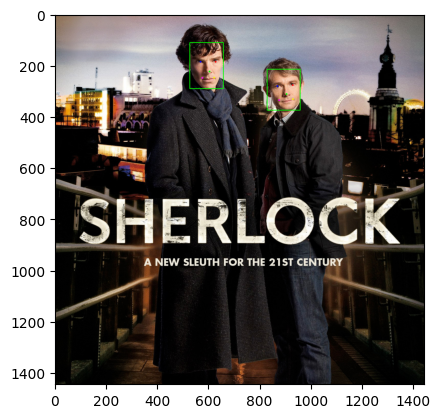

In [42]:
thickness=2 #will be used for bounding box drawing

#Detect sherlock and watson faces
result = detector.detect(image)

if result[1] is not None: #lets check if we have any detected face or not!
    for idx, face in enumerate(result[1]):
        #Extract each face coordinations for drawing bounding box
        coords = face[:-1].astype(np.int32)

        #Draw bounding box and face detected spots:
        #   eyes, mouth corners, nose
        cv2.rectangle(image, (coords[0], coords[1]), (coords[0]+coords[2], coords[1]+coords[3]), (0, 255, 0), thickness)
        cv2.circle(image, (coords[4], coords[5]), 2, (255, 0, 0), thickness)
        cv2.circle(image, (coords[6], coords[7]), 2, (0, 0, 255), thickness)
        cv2.circle(image, (coords[8], coords[9]), 2, (0, 255, 0), thickness)
        cv2.circle(image, (coords[10], coords[11]), 2, (255, 0, 255), thickness)
        cv2.circle(image, (coords[12], coords[13]), 2, (0, 255, 255), thickness)

plt.imshow(image[...,::-1])